# PCB-MC: Fold-Aware Patch Classifier + Two-Stage Pipeline

**Combined Notebook 9 + 10**

Single source: `full_dataset/kfold_data/fold_i/` for all crops, checkpoints, and evaluation.

**Pipeline:**
1. Extract crops per fold from `full_dataset` (present + missing labels)
2. Train ResNet-18 patch classifier per fold with focal loss
3. Oracle evaluation (upper bound — GT crops → classifier)
4. Two-stage detection: YOLO proposals → classifier re-scoring → NMS
5. Full 5-fold evaluation matching Table III protocol

**All results are saved to Google Drive** to survive Colab disconnections.


## [0] Install & Mount Drive

In [1]:
%%capture
!pip install grad-cam scikit-learn ultralytics


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## [1] Imports

In [3]:
import os, json, random, warnings, yaml, shutil
from pathlib import Path
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torchvision import models
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
from tqdm import tqdm
from ultralytics import YOLO

warnings.filterwarnings('ignore')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('torch :', torch.__version__)
print('device:', DEVICE)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
torch : 2.10.0+cu128
device: cuda


## [2] Paths & Configuration

In [4]:
# ── Paths ─────────────────────────────────────────────────────────────────
DATA_ROOT  = '/content/drive/MyDrive/PCB_MC/Data'
YOLO_ROOT  = '/content/drive/MyDrive/PCB_MC/Results/YOLOV11'

# ALL outputs saved directly to Drive — survives Colab disconnections
SAVE_ROOT  = '/content/TwoStage'
CROP_DIR   = os.path.join(SAVE_ROOT, 'crops')
CKPT_DIR   = os.path.join(SAVE_ROOT, 'checkpoints')
RESULT_DIR = os.path.join(SAVE_ROOT, 'results')

for d in [SAVE_ROOT, CROP_DIR, CKPT_DIR, RESULT_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Experiment settings ────────────────────────────────────────────────────
FOLDS            = 5
IMG_EXTS         = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

# Crop extraction
CROP_SIZE        = 128
CONTEXT_FACTOR   = 1.4
MIN_CROP_PX      = 12
PRESENT_TO_MISSING_RATIO = 2.0  # target present:missing ratio per fold

# Classifier training
BATCH_SIZE       = 64
EPOCHS           = 40
LR               = 3e-4
WEIGHT_DECAY     = 1e-4
FOCAL_ALPHA      = 0.75
FOCAL_GAMMA      = 2.0
CLF_THR_ORACLE   = 0.50
VAL_FRAC         = 0.15
PATIENCE         = 10

# Two-stage pipeline
STAGE1_CONF      = 0.05
STAGE1_IOU       = 0.45
STAGE1_IMGSZ     = 1024
CLF_THR_PIPELINE = 0.30
NMS_IOU          = 0.30

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print('Config OK')
print('All outputs will be saved to:', SAVE_ROOT)


Config OK
All outputs will be saved to: /content/TwoStage


## [3] Load Class IDs from data.yaml

In [5]:
yaml_path = os.path.join(
    DATA_ROOT, 'full_dataset', 'kfold_data', 'fold_0', 'data.yaml'
)
with open(yaml_path) as f:
    cfg = yaml.safe_load(f)

CLASS_NAMES = cfg['names']
NC          = cfg['nc']
MISSING_IDS = frozenset(
    i for i, n in enumerate(CLASS_NAMES)
    if n.lower().startswith('missing')
)
PRESENT_IDS = frozenset(
    i for i, n in enumerate(CLASS_NAMES)
    if not n.lower().startswith('missing')
)
print('Total classes:', NC)
print('Missing IDs  :', sorted(MISSING_IDS))
print('Missing names:', [CLASS_NAMES[i] for i in sorted(MISSING_IDS)])


Total classes: 31
Missing IDs  : [15, 16, 17, 18, 19, 20, 21, 22]
Missing names: ['Missing Capacitor', 'Missing Component', 'Missing Diode', 'Missing Ferrite bead', 'Missing IC', 'Missing Inductor', 'Missing Led', 'Missing Resistor']


## [4] Helper Functions

In [6]:
def list_images(folder):
    if not os.path.exists(folder): return []
    return sorted([
        os.path.join(folder, f) for f in os.listdir(folder)
        if f.lower().endswith(IMG_EXTS)
    ])

def read_labels(img_path):
    lp = img_path.replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'
    if not os.path.exists(lp): return []
    rows = []
    with open(lp) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5: continue
            rows.append((int(float(parts[0])), *map(float, parts[1:5])))
    return rows

def yolo_to_xyxy(xc, yc, w, h, W, H):
    x1 = int(max(0, (xc - w/2) * W));  y1 = int(max(0, (yc - h/2) * H))
    x2 = int(min(W-1, (xc + w/2) * W)); y2 = int(min(H-1, (yc + h/2) * H))
    if x2 <= x1: x2 = min(W-1, x1+1)
    if y2 <= y1: y2 = min(H-1, y1+1)
    return x1, y1, x2, y2

def expand_bbox(x1, y1, x2, y2, factor, W, H):
    cx, cy = (x1+x2)/2, (y1+y2)/2
    hw = (x2-x1)/2 * factor;  hh = (y2-y1)/2 * factor
    return (
        int(max(0, cx-hw)),   int(max(0, cy-hh)),
        int(min(W-1, cx+hw)), int(min(H-1, cy+hh))
    )

def iou_xyxy(a, b):
    iw = max(0, min(a[2],b[2]) - max(a[0],b[0]))
    ih = max(0, min(a[3],b[3]) - max(a[1],b[1]))
    inter = iw * ih
    union = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter
    return float(inter / max(union, 1e-9))

def nms(boxes, iou_thr=NMS_IOU):
    keep = []
    for b in sorted(boxes, key=lambda x: x[4], reverse=True):
        if all(iou_xyxy(b[:4], k[:4]) < iou_thr for k in keep):
            keep.append(b)
    return keep

def compute_ap_11pt(scored_tp, total_gt):
    if total_gt == 0: return 0.0
    scored_tp = sorted(scored_tp, key=lambda x: x[0], reverse=True)
    tp = fp = 0;  precs, recs = [], []
    for s, is_tp in scored_tp:
        tp += int(is_tp);  fp += int(1-is_tp)
        precs.append(tp / max(1, tp+fp))
        recs.append(tp / total_gt)
    return float(sum(
        max([p for p, r in zip(precs, recs) if r >= t] + [0.0])
        for t in np.linspace(0, 1, 11)
    ) / 11.0)

def fold_train_images(fold_idx):
    d = os.path.join(DATA_ROOT, 'full_dataset', 'kfold_data',
                     f'fold_{fold_idx}', 'train', 'images')
    return list_images(d)

def fold_val_images(fold_idx):
    d = os.path.join(DATA_ROOT, 'full_dataset', 'kfold_data',
                     f'fold_{fold_idx}', 'valid', 'images')
    return list_images(d)

def save_json(obj, path):
    """Save JSON with float conversion — avoids numpy serialisation errors."""
    def convert(o):
        if isinstance(o, (np.integer,)): return int(o)
        if isinstance(o, (np.floating,)): return float(o)
        if isinstance(o, np.ndarray): return o.tolist()
        raise TypeError
    with open(path, 'w') as f:
        json.dump(obj, f, indent=2, default=convert)
    print('Saved ->', path)

print('Helpers loaded')


Helpers loaded


## [5] Verify Fold Structure

In [7]:
print(f'{'Fold':<6}  {'Train imgs':>12}  {'Val imgs':>10}')
print('-' * 34)
for fi in range(FOLDS):
    tr = fold_train_images(fi)
    va = fold_val_images(fi)
    print(f'  {fi}       {len(tr):>10}    {len(va):>8}')

tr0 = set(os.path.basename(p) for p in fold_train_images(0))
va0 = set(os.path.basename(p) for p in fold_val_images(0))
print(f'\nFold 0 train/val overlap: {len(tr0 & va0)} (must be 0)')


Fold      Train imgs    Val imgs
----------------------------------
  0              492         123
  1              492         123
  2              492         123
  3              492         123
  4              492         123

Fold 0 train/val overlap: 0 (must be 0)


## [6] Per-Fold Crop Extraction

Iterates over `full_dataset/fold_i/train/images` once per fold.
Routes each bounding box by class ID to `missing/` or `present/`.

**Skips folds where crops already exist on Drive** — safe to re-run after
a Colab disconnection without re-extracting from scratch.


In [8]:
def extract_crops_for_fold(fold_idx):
    m_dir = os.path.join(CROP_DIR, f'fold_{fold_idx}', 'missing')
    p_dir = os.path.join(CROP_DIR, f'fold_{fold_idx}', 'present')

    # Skip if already done
    n_existing_m = len(list(Path(m_dir).glob('*.jpg'))) if os.path.exists(m_dir) else 0
    n_existing_p = len(list(Path(p_dir).glob('*.jpg'))) if os.path.exists(p_dir) else 0
    if n_existing_m > 100 and n_existing_p > 100:
        print(f'  Fold {fold_idx}: already extracted '
              f'(missing={n_existing_m}, present={n_existing_p}) — skipping')
        return n_existing_m, n_existing_p

    os.makedirs(m_dir, exist_ok=True)
    os.makedirs(p_dir, exist_ok=True)
    n_miss = n_pres = 0

    for ip in tqdm(fold_train_images(fold_idx),
                   desc=f'Fold {fold_idx} crops', leave=False):
        labs = read_labels(ip)
        if not labs: continue
        img  = Image.open(ip).convert('RGB')
        W, H = img.size
        bn   = os.path.splitext(os.path.basename(ip))[0]

        for idx, (cls, xc, yc, w, h) in enumerate(labs):
            x1, y1, x2, y2 = yolo_to_xyxy(xc, yc, w, h, W, H)
            if (x2-x1) < MIN_CROP_PX or (y2-y1) < MIN_CROP_PX: continue
            x1e, y1e, x2e, y2e = expand_bbox(
                x1, y1, x2, y2, CONTEXT_FACTOR, W, H)
            crop  = img.crop((x1e, y1e, x2e, y2e))
            fname = f'{bn}_{idx:04d}.jpg'

            if cls in MISSING_IDS:
                crop.save(os.path.join(m_dir, fname), quality=92)
                n_miss += 1
            elif cls in PRESENT_IDS:
                crop.save(os.path.join(p_dir, fname), quality=92)
                n_pres += 1
    present_cap = int(n_miss * PRESENT_TO_MISSING_RATIO)
    if n_pres > present_cap:
     all_p = list(Path(p_dir).glob('*.jpg'))
     random.shuffle(all_p)
     for f in all_p[present_cap:]: os.remove(f)
     n_pres = present_cap


    return n_miss, n_pres


print(f'{'Fold':<6}  {'Missing crops':>14}  {'Present crops':>14}  {'Ratio':>8}')
print('-' * 50)
fold_crop_stats = []
for fi in range(FOLDS):
    nm, np_ = extract_crops_for_fold(fi)
    ratio = np_ / max(1, nm)
    fold_crop_stats.append({'fold': fi, 'n_missing': nm,
                             'n_present': np_, 'ratio': ratio})
    print(f'  {fi}       {nm:>14}   {np_:>14}   {ratio:>6.1f}:1')

save_json(fold_crop_stats, os.path.join(RESULT_DIR, 'crop_stats.json'))


Fold     Missing crops   Present crops     Ratio
--------------------------------------------------


  0                 5087            10174      2.0:1


  1                 5160            10320      2.0:1


  2                 4863             9726      2.0:1


  3                 4873             9746      2.0:1


  4                 4393             8786      2.0:1
Saved -> /content/TwoStage/results/crop_stats.json


## [7] Model, Dataset & Loss Definitions

In [9]:
TRAIN_TF = T.Compose([
    T.Resize((CROP_SIZE, CROP_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

EVAL_TF = T.Compose([
    T.Resize((CROP_SIZE, CROP_SIZE)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


class PatchDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths = paths;  self.labels = labels;  self.tf = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        return self.tf(Image.open(self.paths[i]).convert('RGB')), self.labels[i]


def build_loaders(fold_idx):
    m_dir = os.path.join(CROP_DIR, f'fold_{fold_idx}', 'missing')
    p_dir = os.path.join(CROP_DIR, f'fold_{fold_idx}', 'present')
    files  = ([(str(f), 1) for f in Path(m_dir).glob('*.jpg')] +
              [(str(f), 0) for f in Path(p_dir).glob('*.jpg')])
    paths  = [x[0] for x in files]
    labels = [x[1] for x in files]
    tr_p, va_p, tr_l, va_l = train_test_split(
        paths, labels, test_size=VAL_FRAC, stratify=labels, random_state=SEED)
    n_m = sum(1 for l in tr_l if l == 1)
    n_p = sum(1 for l in tr_l if l == 0)
    w   = [1.0/n_p if l == 0 else 1.0/n_m for l in tr_l]
    sampler = WeightedRandomSampler(w, len(tr_l), replacement=True)
    tr_dl = DataLoader(PatchDataset(tr_p, tr_l, TRAIN_TF),
                       batch_size=BATCH_SIZE, sampler=sampler,
                       num_workers=2, pin_memory=True)
    va_dl = DataLoader(PatchDataset(va_p, va_l, EVAL_TF),
                       batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=2, pin_memory=True)
    return tr_dl, va_dl


class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__();  self.alpha = alpha;  self.gamma = gamma
    def forward(self, logits, targets):
        bce    = F.binary_cross_entropy_with_logits(
            logits, targets.float(), reduction='none')
        pt     = torch.exp(-bce)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        return (alpha_t * (1 - pt) ** self.gamma * bce).mean()


def build_model():
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    m.fc = nn.Sequential(
        nn.Linear(m.fc.in_features, 256), nn.ReLU(),
        nn.Dropout(0.3), nn.Linear(256, 1)
    )
    return m.to(DEVICE)


def load_classifier(fold_idx):
    ckpt = os.path.join(CKPT_DIR, f'clf_fold_{fold_idx}.pt')
    assert os.path.exists(ckpt), f'Checkpoint not found: {ckpt}'
    m = build_model()
    # weights_only=False for compatibility with older PyTorch
    m.load_state_dict(torch.load(ckpt, map_location=DEVICE,
                                  weights_only=False))
    return m.to(DEVICE).eval()


@torch.no_grad()
def clf_score_crops(model, crops):
    if not crops: return []
    tensors = torch.stack(
        [EVAL_TF(Image.fromarray(c)) for c in crops]).to(DEVICE)
    return torch.sigmoid(model(tensors).squeeze(1)).cpu().tolist()


print('Definitions OK')


Definitions OK


## [8] Train One Classifier Per Fold

**Checkpoints saved to Drive after each fold** — safe to interrupt and resume.
Folds whose checkpoint already exists are skipped automatically.


In [10]:
def run_epoch(model, loader, criterion, optimizer, train):
    model.train(train)
    tp = fp = fn = total_loss = 0
    with torch.set_grad_enabled(train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits = model(imgs).squeeze(1)
            loss   = criterion(logits, labels)
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * len(imgs)
            preds = (torch.sigmoid(logits) >= CLF_THR_ORACLE).long()
            tp += ((preds==1) & (labels==1)).sum().item()
            fp += ((preds==1) & (labels==0)).sum().item()
            fn += ((preds==0) & (labels==1)).sum().item()
    n   = len(loader.dataset)
    rec = tp / max(1, tp+fn);  pre = tp / max(1, tp+fp)
    f1  = 2*pre*rec / max(1e-9, pre+rec)
    return total_loss/n, 1-rec, f1


def train_fold(fold_idx):
    ckpt = os.path.join(CKPT_DIR, f'clf_fold_{fold_idx}.pt')
    if os.path.exists(ckpt):
        print(f'  Fold {fold_idx}: checkpoint already exists — skipping training')
        return None, []

    print(f'\n=== Training classifier for fold {fold_idx} ===')
    tr_dl, va_dl = build_loaders(fold_idx)
    n_m = sum(1 for _, l in tr_dl.dataset if l == 1)
    n_p = len(tr_dl.dataset) - n_m
    print(f'  Train crops: missing={n_m}, present={n_p}, ratio={n_p/max(1,n_m):.1f}:1')

    model     = build_model()
    criterion = FocalLoss(FOCAL_ALPHA, FOCAL_GAMMA)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR,
                                   weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=EPOCHS)

    best_fnr = 1.0;  no_imp = 0;  history = []

    for ep in range(1, EPOCHS+1):
        tr_loss, tr_fnr, tr_f1 = run_epoch(
            model, tr_dl, criterion, optimizer, train=True)
        va_loss, va_fnr, va_f1 = run_epoch(
            model, va_dl, criterion, optimizer, train=False)
        scheduler.step()
        history.append({'ep': ep, 'tr_fnr': tr_fnr, 'va_fnr': va_fnr,
                         'tr_f1': tr_f1, 'va_f1': va_f1})

        if va_fnr < best_fnr:
            best_fnr = va_fnr;  no_imp = 0
            torch.save(model.state_dict(), ckpt)  # save to Drive
        else:
            no_imp += 1

        if ep % 5 == 0 or ep == 1:
            marker = ' <- best' if no_imp == 0 else ''
            print(f'  Ep {ep:03d} | tr_FNR {tr_fnr:.4f} tr_F1 {tr_f1:.4f} '
                  f'| va_FNR {va_fnr:.4f} va_F1 {va_f1:.4f}{marker}')

        if no_imp >= PATIENCE:
            print(f'  Early stop at epoch {ep}');  break

    print(f'  Best val FNR: {best_fnr:.4f} -> {ckpt}')
    del model;  torch.cuda.empty_cache()
    return best_fnr, history


all_histories  = []
fold_val_fnrs  = []

for fi in range(FOLDS):
    best, hist = train_fold(fi)
    if best is not None:
        fold_val_fnrs.append(best)
    all_histories.append(hist)

if fold_val_fnrs:
    print(f'\nFold val FNRs: {[f"{v:.4f}" for v in fold_val_fnrs]}')
    print(f'Mean: {np.mean(fold_val_fnrs):.4f} +/- {np.std(fold_val_fnrs):.4f}')

# Save training histories
save_json(all_histories,
          os.path.join(RESULT_DIR, 'training_histories.json'))



=== Training classifier for fold 0 ===
  Train crops: missing=4324, present=8647, ratio=2.0:1
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 234MB/s]


  Ep 001 | tr_FNR 0.0474 tr_F1 0.8526 | va_FNR 0.0210 va_F1 0.8351 <- best
  Ep 005 | tr_FNR 0.0151 tr_F1 0.9487 | va_FNR 0.0210 va_F1 0.8951
  Ep 010 | tr_FNR 0.0105 tr_F1 0.9614 | va_FNR 0.0419 va_F1 0.9342
  Early stop at epoch 13
  Best val FNR: 0.0131 -> /content/TwoStage/checkpoints/clf_fold_0.pt

=== Training classifier for fold 1 ===
  Train crops: missing=4386, present=8772, ratio=2.0:1
  Ep 001 | tr_FNR 0.0514 tr_F1 0.8491 | va_FNR 0.0181 va_F1 0.8315 <- best
  Ep 005 | tr_FNR 0.0146 tr_F1 0.9477 | va_FNR 0.0194 va_F1 0.8888
  Ep 010 | tr_FNR 0.0095 tr_F1 0.9633 | va_FNR 0.0168 va_F1 0.9355
  Ep 015 | tr_FNR 0.0079 tr_F1 0.9738 | va_FNR 0.0220 va_F1 0.9498
  Early stop at epoch 19
  Best val FNR: 0.0103 -> /content/TwoStage/checkpoints/clf_fold_1.pt

=== Training classifier for fold 2 ===
  Train crops: missing=4133, present=8267, ratio=2.0:1
  Ep 001 | tr_FNR 0.0597 tr_F1 0.8363 | va_FNR 0.0384 va_F1 0.8239 <- best
  Ep 005 | tr_FNR 0.0157 tr_F1 0.9445 | va_FNR 0.0164 va_F1 

## [9] Oracle Evaluation (Upper Bound)

GT missing crops fed directly to the classifier — no detection involved.
This is the ceiling of the full pipeline: how well the classifier can
distinguish empty footprints from populated ones when given the exact location.


In [11]:
def oracle_eval_fold(fold_idx, thr=CLF_THR_ORACLE):
    model = load_classifier(fold_idx)
    val_imgs = fold_val_images(fold_idx)
    tp = fp = fn = 0

    for ip in tqdm(val_imgs, desc=f'Oracle fold {fold_idx}', leave=False):
        labs = read_labels(ip)
        missing_labs = [l for l in labs if l[0] in MISSING_IDS]
        if not missing_labs: continue
        img = np.array(Image.open(ip).convert('RGB'))
        H, W = img.shape[:2]
        crops = []
        for cls, xc, yc, w, h in missing_labs:
            x1, y1, x2, y2 = yolo_to_xyxy(xc, yc, w, h, W, H)
            x1e, y1e, x2e, y2e = expand_bbox(
                x1, y1, x2, y2, CONTEXT_FACTOR, W, H)
            cr = img[y1e:y2e, x1e:x2e]
            if cr.size > 0: crops.append(cr)
        for score in clf_score_crops(model, crops):
            if score >= thr: tp += 1
            else:            fn += 1

    del model;  torch.cuda.empty_cache()
    prec = tp / max(1, tp+fp)
    rec  = tp / max(1, tp+fn)
    f1   = 2*prec*rec / max(1e-9, prec+rec)
    return {'fold': fold_idx, 'tp': tp, 'fn': fn, 'fp': fp,
            'precision': prec, 'recall': rec, 'f1': f1, 'fnr': 1-rec}


oracle_results = [oracle_eval_fold(fi) for fi in range(FOLDS)]

# Print table
print(f'{'Fold':<6}  {'TP':>6}  {'FN':>6}  {'Precision':>10}  '
      f'{'Recall':>8}  {'F1':>8}  {'FNR':>8}')
print('-' * 62)
for r in oracle_results:
    print(f'  {r["fold"]}      {r["tp"]:>6}  {r["fn"]:>6}  '
          f'{r["precision"]:>10.4f}  {r["recall"]:>8.4f}  '
          f'{r["f1"]:>8.4f}  {r["fnr"]:>8.4f}')
print('-' * 62)
mean_fnr = np.mean([r['fnr'] for r in oracle_results])
std_fnr  = np.std( [r['fnr'] for r in oracle_results])
mean_f1  = np.mean([r['f1']  for r in oracle_results])
print(f'  MEAN   {'':>6}  {'':>6}  '
      f'{np.mean([r["precision"] for r in oracle_results]):>10.4f}  '
      f'{np.mean([r["recall"]    for r in oracle_results]):>8.4f}  '
      f'{mean_f1:>8.4f}  {mean_fnr:>8.4f}')
print(f'  STD    {'':>6}  {'':>6}  '
      f'{np.std([r["precision"] for r in oracle_results]):>10.4f}  '
      f'{np.std([r["recall"]    for r in oracle_results]):>8.4f}  '
      f'{np.std([r["f1"]        for r in oracle_results]):>8.4f}  '
      f'{std_fnr:>8.4f}')
print(f'\nYOLO baseline FNR  : 0.87')
print(f'Oracle FNR (ours)  : {mean_fnr:.4f} +/- {std_fnr:.4f}')
print(f'Absolute gain      : {0.87 - mean_fnr:.4f}')

save_json(oracle_results,
          os.path.join(RESULT_DIR, 'oracle_results.json'))


Fold        TP      FN   Precision    Recall        F1       FNR
--------------------------------------------------------------
  0        1439      97      1.0000    0.9368    0.9674    0.0632
  1        1276     170      1.0000    0.8824    0.9375    0.1176
  2        1227     985      1.0000    0.5547    0.7136    0.4453
  3        1512      71      1.0000    0.9551    0.9771    0.0449
  4        2606      52      1.0000    0.9804    0.9901    0.0196
--------------------------------------------------------------
  MEAN                       1.0000    0.8619    0.9171    0.1381
  STD                        0.0000    0.1569    0.1032    0.1569

YOLO baseline FNR  : 0.87
Oracle FNR (ours)  : 0.1381 +/- 0.1569
Absolute gain      : 0.7319
Saved -> /content/TwoStage/results/oracle_results.json


## [10] Two-Stage Detection Pipeline

**Stage 1**: YOLOv11 `full_dataset/fold_i` at conf=0.05 → candidate boxes  
**Stage 2**: `clf_fold_i.pt` re-scores each candidate → P(missing)  
Boxes with P(missing) ≥ 0.30 are kept; final NMS removes duplicates.


In [12]:
@torch.no_grad()
def get_yolo_proposals(yolo_model, img_path):
    result = yolo_model.predict(
        img_path, conf=STAGE1_CONF, iou=STAGE1_IOU,
        imgsz=STAGE1_IMGSZ, verbose=False)[0]
    if result.boxes is None or len(result.boxes) == 0:
        return []
    boxes = result.boxes.xyxy.cpu().numpy()
    confs = result.boxes.conf.cpu().numpy()
    return [(int(x1), int(y1), int(x2), int(y2), float(c))
            for (x1, y1, x2, y2), c in zip(boxes, confs)]


def two_stage_detect(yolo_model, clf_model, img_path,
                     clf_thr=CLF_THR_PIPELINE):
    img = np.array(Image.open(img_path).convert('RGB'))
    H, W = img.shape[:2]
    proposals = get_yolo_proposals(yolo_model, img_path)
    if not proposals: return [], 0

    crops, meta = [], []
    for (x1, y1, x2, y2, _) in proposals:
        x1e, y1e, x2e, y2e = expand_bbox(
            x1, y1, x2, y2, CONTEXT_FACTOR, W, H)
        cr = img[y1e:y2e, x1e:x2e]
        if cr.size == 0: continue
        crops.append(cr);  meta.append((x1, y1, x2, y2))

    if not crops: return [], len(proposals)
    scores = clf_score_crops(clf_model, crops)
    detections = [(x1, y1, x2, y2, sc)
                  for (x1, y1, x2, y2), sc in zip(meta, scores)
                  if sc >= clf_thr]
    return nms(detections, NMS_IOU), len(proposals)


print('Pipeline defined')


Pipeline defined


## [11] 5-Fold Cross-Validated Evaluation

For each fold: load matching YOLO + classifier checkpoints,
evaluate on `fold_i/valid/images`, GT = missing boxes only.

**Results saved to Drive after every fold** — safe to interrupt.


In [13]:
def evaluate_fold(fold_idx, clf_thr=CLF_THR_PIPELINE):
    yolo_ckpt = os.path.join(
        YOLO_ROOT, 'full_dataset',
        f'fold_{fold_idx}', 'weights', 'best.pt')
    yolo = YOLO(yolo_ckpt)
    clf  = load_classifier(fold_idx)

    val_imgs   = fold_val_images(fold_idx)
    total_gt   = tp = fp = 0
    scored_tp  = []
    total_props = 0

    for ip in tqdm(val_imgs, desc=f'Pipeline fold {fold_idx}', leave=False):
        labs = read_labels(ip)
        img  = np.array(Image.open(ip).convert('RGB'))
        H, W = img.shape[:2]
        gt = [yolo_to_xyxy(xc, yc, w, h, W, H)
              for (cls, xc, yc, w, h) in labs if cls in MISSING_IDS]
        total_gt += len(gt)
        if not gt: continue

        preds, n_props = two_stage_detect(yolo, clf, ip, clf_thr)
        total_props += n_props

        gt_used = [False] * len(gt)
        for (x1, y1, x2, y2, sc) in preds:
            best_i, best_iou = -1, 0.0
            for i, g in enumerate(gt):
                if gt_used[i]: continue
                v = iou_xyxy((x1, y1, x2, y2), g)
                if v > best_iou: best_i, best_iou = i, v
            if best_i >= 0 and best_iou >= 0.5:
                gt_used[best_i] = True;  tp += 1
                scored_tp.append((sc, 1))
            else:
                fp += 1;  scored_tp.append((sc, 0))

    del yolo, clf;  torch.cuda.empty_cache()
    prec = tp / max(1, tp+fp)
    rec  = tp / max(1, total_gt)
    f1   = 2*prec*rec / max(1e-9, prec+rec)
    return {'fold': fold_idx, 'total_gt': total_gt,
            'tp': tp, 'fp': fp, 'total_proposals': total_props,
            'precision': prec, 'recall': rec, 'f1': f1,
            'fnr': 1-rec, 'ap50': compute_ap_11pt(scored_tp, total_gt)}


print('Running 5-fold pipeline evaluation...')
pipeline_results = []

for fi in range(FOLDS):
    r = evaluate_fold(fi)
    pipeline_results.append(r)
    print(f'Fold {fi}: GT={r["total_gt"]} TP={r["tp"]} FP={r["fp"]} '
          f'mAP={r["ap50"]:.4f} F1={r["f1"]:.4f} FNR={r["fnr"]:.4f}')
    # Save after every fold — safe to interrupt
    save_json(pipeline_results,
              os.path.join(RESULT_DIR, 'pipeline_results_partial.json'))

ap_vals  = [r['ap50'] for r in pipeline_results]
f1_vals  = [r['f1']   for r in pipeline_results]
fnr_vals = [r['fnr']  for r in pipeline_results]

summary = {
    'fold_results': pipeline_results,
    'summary': {
        'mean_ap':  float(np.mean(ap_vals)),  'std_ap':  float(np.std(ap_vals)),
        'mean_f1':  float(np.mean(f1_vals)),  'std_f1':  float(np.std(f1_vals)),
        'mean_fnr': float(np.mean(fnr_vals)), 'std_fnr': float(np.std(fnr_vals)),
        'mean_prec':float(np.mean([r['precision'] for r in pipeline_results])),
    }
}
save_json(summary, os.path.join(RESULT_DIR, 'pipeline_results_final.json'))

print('=' * 60)
print(f'MEAN  mAP={np.mean(ap_vals):.4f}+/-{np.std(ap_vals):.4f}  '
      f'F1={np.mean(f1_vals):.4f}+/-{np.std(f1_vals):.4f}  '
      f'FNR={np.mean(fnr_vals):.4f}+/-{np.std(fnr_vals):.4f}')


Running 5-fold pipeline evaluation...


Fold 0: GT=1536 TP=271 FP=4859 mAP=0.0713 F1=0.0813 FNR=0.8236
Saved -> /content/TwoStage/results/pipeline_results_partial.json


Fold 1: GT=1446 TP=499 FP=3414 mAP=0.2197 F1=0.1862 FNR=0.6549
Saved -> /content/TwoStage/results/pipeline_results_partial.json


Fold 2: GT=2212 TP=456 FP=3495 mAP=0.1230 F1=0.1480 FNR=0.7939
Saved -> /content/TwoStage/results/pipeline_results_partial.json


Fold 3: GT=1583 TP=504 FP=4858 mAP=0.1834 F1=0.1451 FNR=0.6816
Saved -> /content/TwoStage/results/pipeline_results_partial.json


Fold 4: GT=2658 TP=549 FP=10731 mAP=0.1286 F1=0.0788 FNR=0.7935
Saved -> /content/TwoStage/results/pipeline_results_partial.json
Saved -> /content/TwoStage/results/pipeline_results_final.json
MEAN  mAP=0.1452+/-0.0515  F1=0.1279+/-0.0417  FNR=0.7495+/-0.0677


## [12] Comparison Table vs All Baselines

In [14]:
baselines = [
    ('YOLOv8  (conf=0.25)',  0.09, 0.15, 0.90),
    ('YOLOv11 (conf=0.25)',  0.08, 0.15, 0.87),
    ('YOLOv26 (conf=0.25)',  0.09, 0.15, 0.87),
    ('RT-DETR (conf=0.25)',  0.04, 0.11, 0.92),
    ('D-FINE  (conf=0.25)',  0.03, 0.04, 0.93),
]

print(f'{'Method':<40}  {'mAP@0.5':>9}  {'F1':>8}  {'FNR':>8}')
print('-' * 70)
for name, ap, f1, fnr in baselines:
    print(f'  {name:<38}  {ap:>9.4f}  {f1:>8.4f}  {fnr:>8.4f}')
print('-' * 70)
# Oracle
or_fnr = np.mean([r['fnr'] for r in oracle_results])
or_f1  = np.mean([r['f1']  for r in oracle_results])
print(f'  {'Patch-CLF Oracle (upper bound)':<38}  '
      f'  {'—':>8}  {or_f1:>8.4f}  {or_fnr:>8.4f}')
# Pipeline
print(f'  {'Two-Stage YOLO+PatchCLF (ours)':<38}  '
      f'{np.mean(ap_vals):>9.4f}  {np.mean(f1_vals):>8.4f}  '
      f'{np.mean(fnr_vals):>8.4f}')
print('-' * 70)
print(f'DELTA FNR vs best YOLO : {np.mean(fnr_vals)-0.87:+.4f}')
print(f'DELTA mAP vs best YOLO : {np.mean(ap_vals)-0.09:+.4f}')


Method                                      mAP@0.5        F1       FNR
----------------------------------------------------------------------
  YOLOv8  (conf=0.25)                        0.0900    0.1500    0.9000
  YOLOv11 (conf=0.25)                        0.0800    0.1500    0.8700
  YOLOv26 (conf=0.25)                        0.0900    0.1500    0.8700
  RT-DETR (conf=0.25)                        0.0400    0.1100    0.9200
  D-FINE  (conf=0.25)                        0.0300    0.0400    0.9300
----------------------------------------------------------------------
  Patch-CLF Oracle (upper bound)                   —    0.9171    0.1381
  Two-Stage YOLO+PatchCLF (ours)             0.1452    0.1279    0.7495
----------------------------------------------------------------------
DELTA FNR vs best YOLO : -0.1205
DELTA mAP vs best YOLO : +0.0552


## [13] Stage-1 Proposal Recall (Ceiling Analysis)

What fraction of GT missing boxes does YOLO propose at conf=0.05?
This is the hard ceiling of the pipeline — Stage 2 cannot recover
boxes that Stage 1 never proposes.

Run on fold 0 only for speed (~5 min).


In [15]:
def stage1_recall_analysis(fold_idx=0):
    yolo_ckpt = os.path.join(
        YOLO_ROOT, 'full_dataset',
        f'fold_{fold_idx}', 'weights', 'best.pt')
    yolo = YOLO(yolo_ckpt)
    val_imgs = fold_val_images(fold_idx)
    total_gt = proposed = 0

    for ip in tqdm(val_imgs, desc=f'S1 recall fold {fold_idx}'):
        labs = read_labels(ip)
        img  = np.array(Image.open(ip).convert('RGB'))
        H, W = img.shape[:2]
        gt = [yolo_to_xyxy(xc, yc, w, h, W, H)
              for (cls, xc, yc, w, h) in labs if cls in MISSING_IDS]
        total_gt += len(gt)
        if not gt: continue
        props = get_yolo_proposals(yolo, ip)
        covered = [False] * len(gt)
        for (x1, y1, x2, y2, _) in props:
            for i, g in enumerate(gt):
                if not covered[i] and iou_xyxy((x1,y1,x2,y2), g) >= 0.5:
                    covered[i] = True
        proposed += sum(covered)

    del yolo;  torch.cuda.empty_cache()
    s1_rec = proposed / max(1, total_gt)
    print(f'Stage-1 analysis (fold {fold_idx}, conf={STAGE1_CONF})')
    print(f'  GT missing boxes  : {total_gt}')
    print(f'  Proposed by YOLO  : {proposed}')
    print(f'  Stage-1 Recall    : {s1_rec:.4f}')
    print(f'  Pipeline FNR ceil : {1-s1_rec:.4f}')
    print(f'  (Oracle FNR = {np.mean([r["fnr"] for r in oracle_results]):.4f}, '
          f'Pipeline FNR = {np.mean(fnr_vals):.4f})')
    save_json({'fold': fold_idx, 'total_gt': total_gt,
               'proposed': proposed, 's1_recall': s1_rec},
              os.path.join(RESULT_DIR, 'stage1_recall.json'))
    return s1_rec


s1_rec = stage1_recall_analysis(fold_idx=0)


S1 recall fold 0: 100%|██████████| 123/123 [00:07<00:00, 16.81it/s]

Stage-1 analysis (fold 0, conf=0.05)
  GT missing boxes  : 1536
  Proposed by YOLO  : 279
  Stage-1 Recall    : 0.1816
  Pipeline FNR ceil : 0.8184
  (Oracle FNR = 0.1381, Pipeline FNR = 0.7495)
Saved -> /content/TwoStage/results/stage1_recall.json


## [14] Qualitative Comparison

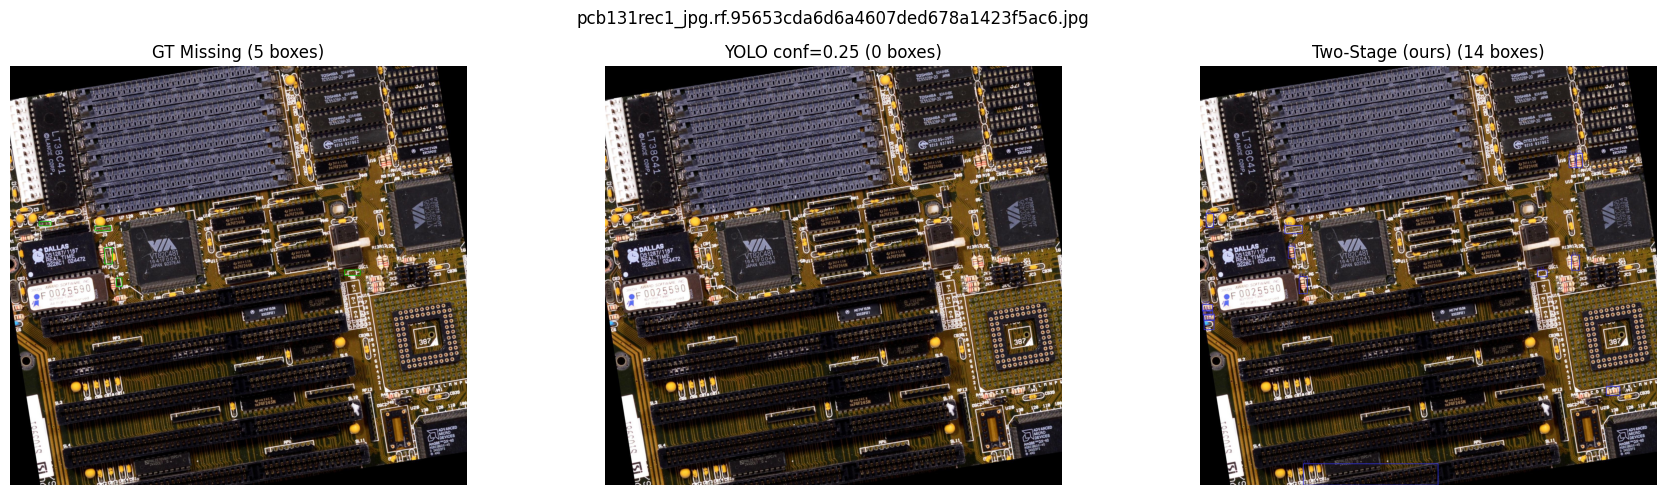

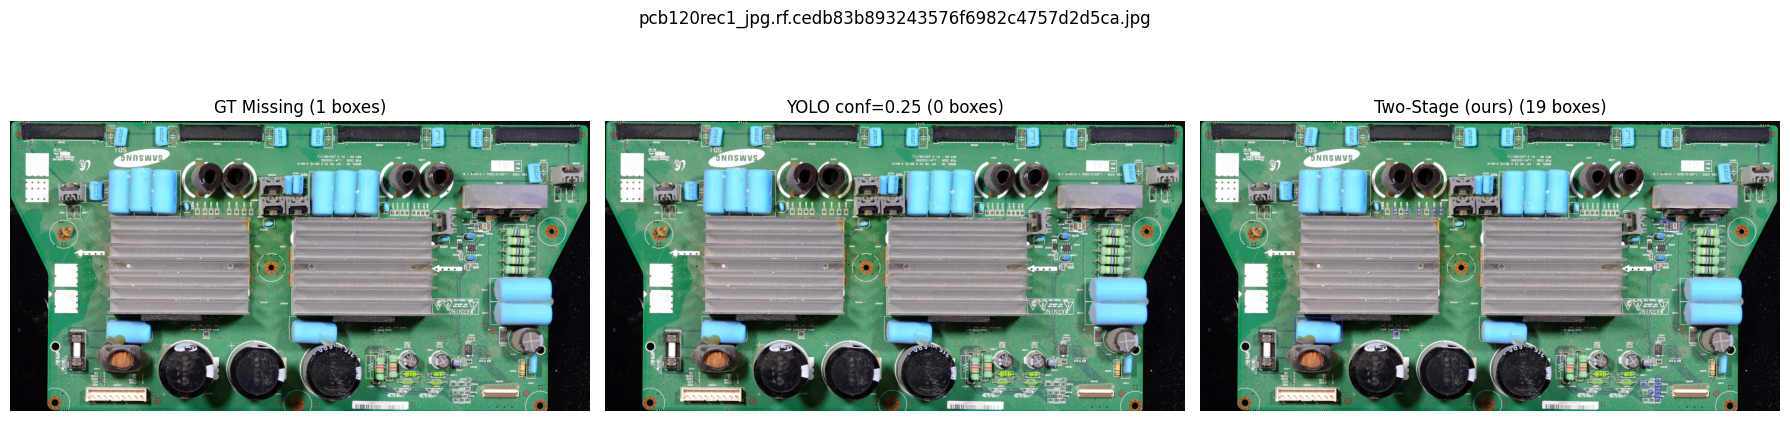

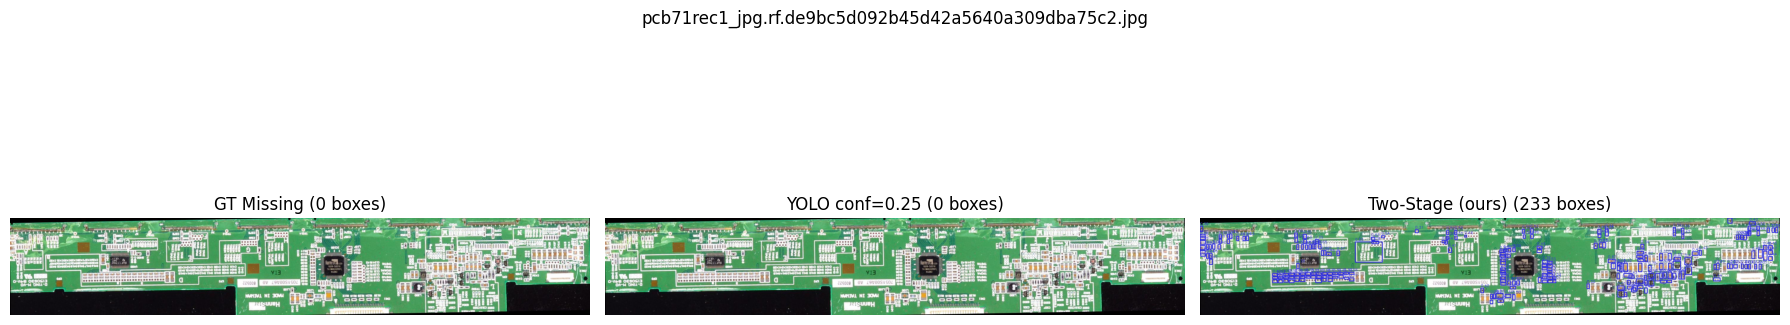

In [18]:
def visualise(img_path, fold_idx=0, clf_thr=CLF_THR_PIPELINE):
    yolo_ckpt = os.path.join(
        YOLO_ROOT, 'full_dataset',
        f'fold_{fold_idx}', 'weights', 'best.pt')
    yolo = YOLO(yolo_ckpt)
    clf  = load_classifier(fold_idx)
    img  = np.array(Image.open(img_path).convert('RGB'))
    H, W = img.shape[:2]
    labs = read_labels(img_path)
    gt   = [yolo_to_xyxy(xc, yc, w, h, W, H)
            for (cls, xc, yc, w, h) in labs if cls in MISSING_IDS]

    # YOLO at conf=0.25, missing classes only
    res_std = yolo.predict(img_path, conf=0.25,
                            imgsz=STAGE1_IMGSZ, verbose=False)[0]
    yolo_missing = []
    if res_std.boxes is not None:
        for (x1,y1,x2,y2), c, cl in zip(
            res_std.boxes.xyxy.cpu().numpy(),
            res_std.boxes.conf.cpu().numpy(),
            res_std.boxes.cls.cpu().numpy().astype(int)):
            if int(cl) in MISSING_IDS:
                yolo_missing.append((int(x1),int(y1),int(x2),int(y2),float(c)))

    ts_preds, _ = two_stage_detect(yolo, clf, img_path, clf_thr)
    del yolo, clf;  torch.cuda.empty_cache()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    panels = [
        ('GT Missing',      (0, 200, 0),   [(b+(None,)) for b in gt]),
        ('YOLO conf=0.25',  (220, 100, 0), yolo_missing),
        ('Two-Stage (ours)',(50, 50, 220), ts_preds),
    ]
    for ax, (title, color, boxes) in zip(axes, panels):
        vis = img.copy()
        for *b, sc in boxes:
            x1,y1,x2,y2 = int(b[0]),int(b[1]),int(b[2]),int(b[3])
            cv2.rectangle(vis, (x1,y1), (x2,y2), color, 2)
            if sc is not None:
                cv2.putText(vis, f'{sc:.2f}', (x1, max(0,y1-4)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
        ax.imshow(vis)
        ax.set_title(f'{title} ({len(boxes)} boxes)')
        ax.axis('off')
    plt.suptitle(os.path.basename(img_path))
    plt.tight_layout()
    plt.show()


val0 = fold_val_images(0)
for p in random.sample(val0, min(3, len(val0))):
    visualise(p, fold_idx=0)


## [15] Training Curves

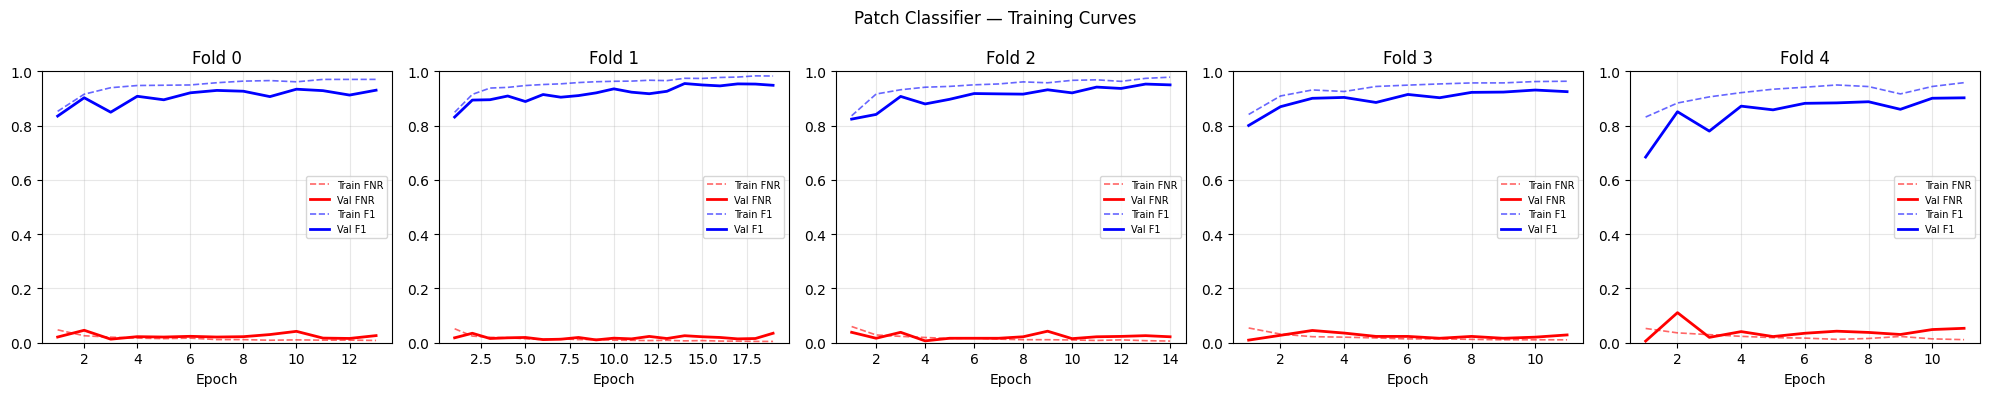

Saved training_curves.png to /content/TwoStage/results


In [17]:
histories_with_data = [h for h in all_histories if len(h) > 0]
if histories_with_data:
    n = len(histories_with_data)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1: axes = [axes]
    for fi, (hist, ax) in enumerate(zip(histories_with_data, axes)):
        eps    = [h['ep']     for h in hist]
        tr_fnr = [h['tr_fnr'] for h in hist]
        va_fnr = [h['va_fnr'] for h in hist]
        tr_f1  = [h['tr_f1']  for h in hist]
        va_f1  = [h['va_f1']  for h in hist]
        ax.plot(eps, tr_fnr, 'r--', lw=1.2, alpha=0.6, label='Train FNR')
        ax.plot(eps, va_fnr, 'r-',  lw=2.0, label='Val FNR')
        ax.plot(eps, tr_f1,  'b--', lw=1.2, alpha=0.6, label='Train F1')
        ax.plot(eps, va_f1,  'b-',  lw=2.0, label='Val F1')
        ax.set_title(f'Fold {fi}')
        ax.set_xlabel('Epoch')
        ax.set_ylim(0, 1)
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)
    plt.suptitle('Patch Classifier — Training Curves')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULT_DIR, 'training_curves.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved training_curves.png to', RESULT_DIR)
else:
    print('No new training histories (all folds used existing checkpoints)')
